## Section I. Introduction
The dataset chosen for this study is the [***"Pediatric Anemia Dataset: Hematological Indicators and Diagnostic Classification"***](https://data.mendeley.com/datasets/y7v7ff3wpj/1). This dataset contains hematological parameters used to support the diagnosis of anemia among patients.

Anemia is a medical condition characterized by a deficiency in healthy red blood cells or hemoglobin, which reduces the blood’s capacity to transport oxygen to body tissues. This condition remains a significant public health concern, particularly in tropical and subtropical regions. Early detection and appropriate treatment using hematological indicators such as hemoglobin level and red blood cell count are essential in addressing this condition.

With this, the goal of this study is to predict the clinical diagnostic outcome of anemia using demographic and hematological parameters. Therefore, the task is a binary classification task, where the model aims to classify patients into either: anemic or non-anemic. 

Since we look to test different machine learning models to find the best performing one, it is important to note that we will be utilizing **recall** as our main metric for tuning our models. Because we look to properly identify anemic patients, it is more important to gauge whether our models are able to correctly identify all the existing anemic patients in the data, rather than perfectly identifying each and every patient (i.e. accuracy).

## Section II. Description of the Dataset
The dataset used in this study was obtained from the publicly available anemia clinical dataset published on [Mendeley Data](https://data.mendeley.com/datasets/y7v7ff3wpj/1). The data were collected from anemia patients in Aalok Healthcare Ltd., located in Dhaka, Bangladesh on October 9, 2023. 

Each row in the dataset represents a patients's record, and each corresponding column represent a specific attribute. The dataset consists of **1000 observations** and **8 features**, with an additional target variable (Decision_Class). 

The following are the description of each feature of the dataset:

- **`Gender`**: biological sex of the patient; `m` for male or `f` for female
- **`Age`**: age of the patient (years)
- **`Hb (hemoglobin)`**: measure of the blood's capacity to carry oxygen (g/dL)
- **`RBC (red blood cell count)`**: number of red blood cells per unit volume (million/μL)
- **`PCV (packed cell volume)`**: percentage of red blood cells in blood volume
- **`MCV (mean corpuscular volume)`**: average size of red blood cells (fL)
- **`MCH (mean corpuscular hemoglobin)`**: average hemoglobin content per red blood cell (pg/cell)
- **`MCHC (mean corpuscular hemoglobin concentration )`**: concentration of hemoglobin in red blood cells (g/dL)
- **`Decision_Class`**: binary indicator for the diagnostic outcome; `0` for non-anemic or `1` for anemic

## Import

In [835]:
import numpy as np
import pandas as pd
import torch
import torch.optim as optim
import torch.nn as nn
import csv
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn.preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## Section III. Data Preparation

### Reading the Dataset
The first step is to load the dataset `anemia.csv`.

In [836]:
anemia_df = pd.read_csv('anemia.csv')

To quickly view the structure of the dataset, we use the function `head()`.

In [837]:
anemia_df.head(10)

,Gender,Age,Hb,RBC,PCV,MCV,MCH,MCHC,Decision_Class
0,f,32,10.9,4.26,34.2,80.2,25.5,31.8,1
1,f,45,9.6,3.64,29.9,82.1,26.4,32.2,1
2,f,38,10.1,3.70,32.4,87.6,27.4,31.3,1
3,m,37,11.0,3.93,33.6,85.3,27.9,32.7,1
4,f,50,12.1,4.16,36.5,87.9,29.2,33.2,0
5,f,40,10.4,3.59,30.4,84.5,27.7,32.7,1
6,f,32,6.8,1.99,15.4,77.4,24.0,31.0,1
7,m,18,11.6,4.06,35.5,87.4,28.6,32.8,1
8,m,38,12.0,4.38,36.3,82.8,27.5,33.2,0
9,f,50,11.7,4.35,36.6,84.0,26.9,32.0,1


In [838]:
anemia_df.shape

(1000, 9)

The loaded dataset information shows that the dataset contains **1,000 rows** and **9 columns**, confirming that the dataset has been loaded succesfully.

To improve readability and consistency, the dataset column names were renamed.

In [839]:
anemia_df = anemia_df.rename(columns={'Gender': 'gender', 
                              'Age': 'age', 
                              'Hb': 'hb', 
                              'RBC': 'rbc', 
                              'PCV': 'pcv', 
                              'MCV': 'mcv',
                              'MCH': 'mch',
                              'MCHC': 'mchc',
                              'Decision_Class': 'decision'})

### Data Cleaning

#### Checking multiple representations
To ensure consistent formatting, multiple representations of values in the **gender** column were checked. 
The values of the **gender** column were inspected using the `unique()` function to identify all existing categorical representations in the dataset.

In [840]:
anemia_df['gender'].unique()

array(['f', 'm'], dtype=object)

The output confirmed that gender was represented using two categories: `f` for female and `m` for male.

#### Checking data types
To check whether each variable is in the appropriate format, we use the `.dtypes`.

In [841]:
anemia_df.dtypes

gender       object
age           int64
hb          float64
rbc         float64
pcv         float64
mcv         float64
mch         float64
mchc        float64
decision      int64
dtype: object

In [842]:
anemia_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   gender    1000 non-null   object 
 1   age       1000 non-null   int64  
 2   hb        1000 non-null   float64
 3   rbc       1000 non-null   float64
 4   pcv       1000 non-null   float64
 5   mcv       1000 non-null   float64
 6   mch       1000 non-null   float64
 7   mchc      1000 non-null   float64
 8   decision  1000 non-null   int64  
dtypes: float64(6), int64(2), object(1)
memory usage: 70.4+ KB


The output shows that all variables are stored using appropriate and consistent data types. For **discrete variables** such as age and the target classification variable, the data are stored as **integer** values, while **continuous** hematological parameters are stored as **floating-point** values, and gender is stored as **string** values.

#### Handling missing values
To check for any missing values in our dataset, we use the `isnull()` function along with `sum`.

In [843]:
print(anemia_df.isnull().sum())

gender      0
age         0
hb          0
rbc         0
pcv         0
mcv         0
mch         0
mchc        0
decision    0
dtype: int64


The output shows there are **no missing values** in the dataset.

#### Handling duplicates
To check for any duplicate records, we use the `duplicated()` along with `sum`.

In [844]:
print(anemia_df.duplicated().sum())

28


The output showed that there were **28 duplicate records** in the dataset. To further examine these duplicate entries, we display all duplicated rows:

In [845]:
anemia_df[anemia_df.duplicated(keep=False)]

,gender,age,hb,rbc,pcv,mcv,mch,mchc,decision
10,f,30,11.4,5.51,35.4,64.3,20.6,32.1,1
15,f,30,11.4,5.51,35.4,64.3,20.6,32.1,1
207,f,49,10.8,3.62,27.9,77.0,26.7,34.7,1
208,f,45,10.9,4.36,31.8,72.9,25.0,34.3,1
209,f,52,11.8,4.37,34.9,80.0,27.1,33.9,1
210,f,49,10.8,3.62,27.9,77.0,26.7,34.7,1
211,f,45,10.9,4.36,31.8,72.9,25.0,34.3,1
212,f,52,11.8,4.37,34.9,80.0,27.1,33.9,1
224,f,29,11.1,3.57,29.5,82.7,31.2,37.8,1
225,f,20,11.9,4.34,32.2,74.1,27.4,37.0,1


Since duplicate records can affect model performance and analysis, the duplicate entries we'll be removed from the dataset.

In [846]:
anemia_df = anemia_df.drop_duplicates()

After removing duplicates, the dataset was rechecked to confirm that no duplicate records remained:

In [847]:
print(anemia_df.duplicated().sum())

0


The output confirmed that duplicate records were successfully removed.

In [848]:
anemia_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 972 entries, 0 to 999
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   gender    972 non-null    object 
 1   age       972 non-null    int64  
 2   hb        972 non-null    float64
 3   rbc       972 non-null    float64
 4   pcv       972 non-null    float64
 5   mcv       972 non-null    float64
 6   mch       972 non-null    float64
 7   mchc      972 non-null    float64
 8   decision  972 non-null    int64  
dtypes: float64(6), int64(2), object(1)
memory usage: 75.9+ KB


The dataset now contains **972 unique patient records**. 

With the data cleaning process completed, we proceed to the exploratory data analysis (EDA) phase to examine data distributions and relationships between variables.

## Section IV. Exploratory Data Analysis (EDA)

In [849]:
gender = anemia_df['gender']
age = anemia_df['age']
hb = anemia_df['hb']
rbc = anemia_df['rbc']
pcv = anemia_df['pcv']
mcv = anemia_df['mcv']
mch = anemia_df['mch']
mchc = anemia_df['mchc']
decision = anemia_df['decision']

### A. Descriptive Statistics
Before visualizing the data, we examine the **descriptive analysis** of each feature to better understand its central tendency, spread, and range.

#### Age
The `age` variable represents the patient's age in years.

In [850]:
anemia_df['age'].describe().round(4)

count    972.0000
mean      40.9187
std       16.0336
min       18.0000
25%       28.0000
50%       38.0000
75%       51.2500
max       96.0000
Name: age, dtype: float64

The age of patients ranges from **18 to 96 years**, with a mean of approximately **41 years** and a standard deviation of ~16 years. The interquartile range spans from **28 to 51 years**. Hence, we can infer that majority of patients fall within a working-age adult range.

#### Hb (Hemoglobin)
 - `hb` is the protein found in red blood cells that facilitates the transport of oxygen to the tissues. The normal reference range is 12 to 16 g/dL for females and 14 to 18 g/dL for males. [1]

In [851]:
anemia_df['hb'].describe().round(4)

count    972.0000
mean      11.5662
std        1.3455
min        5.5000
25%       10.8000
50%       11.6000
75%       12.2000
max       15.8000
Name: hb, dtype: float64

Hemoglobin values range from **5.50 to 15.80 g/dL**, with a mean of approximately **11.57 g/dL**. It seems that the mean already **falls below the normal threshold** for both sexes. This is further supported by the Q3 of ~12.2 g/dL, which tells us that at least 75% of patients have Hb values that are at or below the lower boundary of the normal range.

#### RBC (Red Blood Cells)
- `rbc` measures the number of red blood cells per unit volume of blood. The normal reference range is 4.3-5.9 million/μL for males and 3.5-5.5 million/μL for females. [2]

In [852]:
anemia_df['rbc'].describe().round(4)

count    972.0000
mean       4.1341
std        0.6001
min        1.4700
25%        3.7700
50%        4.1100
75%        4.4700
max        7.4100
Name: rbc, dtype: float64

RBC values range from **1.47 to 7.41 million/μL**, with a mean of approximately **4.13 million/μL**. The minimum value of 1.47 is markedly low. Additionally, the Q1 of ~3.77 million/μL tells us that at least 25% of patients fall below or near the lower boundary of the normal range.

#### PCV (Packed Cell Volume)
- `pcv` measures the percentage of blood volume occupied by red blood cells. The normal range is approximately 35–47% for females and 40–52% for males. [3]

In [853]:
anemia_df['pcv'].describe().round(4)

count    972.0000
mean      32.6622
std        4.8991
min       10.6000
25%       29.8000
50%       32.8000
75%       35.7250
max       49.5000
Name: pcv, dtype: float64

PCV values range from **10.60% to 49.50%**, with a mean of approximately **32.66%**. This means that on average, patients have PCV levels below the normal lower bound for both sexes. The minimum of 10.6% is particularly noticeable. This is a critically low level and is consistent with the RBC and Hb findings above.

#### MCV (Mean Corpuscular Volume)
- `mcv` measures the average size of red blood cells in femtoliters (fL). The normal range is 80–100 fL; values below indicate microcytic and above indicate macrocytic red cells. [2]

In [854]:
anemia_df['mcv'].describe().round(4)

count    972.0000
mean      79.2242
std        7.8101
min       29.6000
25%       75.2000
50%       80.7000
75%       84.5000
max      104.9000
Name: mcv, dtype: float64

MCV values range from **29.60 to 104.90 fL**, with a mean of approximately **79.22 fL**. While the mean is somewhat near the normal range, the minimum of 29.60 fL indicates the presence of 'probable' microcytic cases in the dataset [8]. It seems that at least 25% of patients have MCV below the normal lower bound, as suggested by the Q1 of 75.20 fL.

#### MCH (Mean Corpuscular Hemoglobin)
- `mch` is the average amount of hemoglobin per red blood cell. The normal range is 25.4-34.6 pg/cell. [2]

In [855]:
anemia_df['mch'].describe().round(4)

count    972.0000
mean      28.1362
std        3.3508
min       13.3000
25%       26.3000
50%       28.7000
75%       30.4000
max       37.9000
Name: mch, dtype: float64

MCH values range from **13.30 to 37 pg/cell**, with a mean of approximately **28.14 pg/cell**. The mean suggests that a considerable number of patients are in normal lower boundary MCH levels.

#### MCHC (Mean Corpuscular Hemoglobin Concentration)
- `mchc` measures the concentration of hemoglobin in red blood cells. The normal range is 32-36 g/dL. [4]

In [856]:
anemia_df['mchc'].describe().round(4)

count    972.0000
mean      35.4145
std        1.4229
min       25.3000
25%       34.9000
50%       35.7000
75%       36.3000
max       38.1000
Name: mchc, dtype: float64

MCHC values range from **25.30 to 38.10 g/dL**, with a mean of approximately **35.41 g/dL**. This means that on average, patients fall within the normal reference range for MCHC. However, the minimum of 25.30 g/dL is notably low, which may indicate 'probable' hypochromic anemia (low mchc), in some cases. Among all hematological features, MCHC shows the smallest range.

### B. Target Variable Distribution

The target variable `decision` represents a binary indicator (1 for anemic; 0 for non-anemic) for the diagnostic outcome. 

Let's first take a look at how the anemic and non-anemic cases are distributed in the dataset to get a general sense of the class balance.


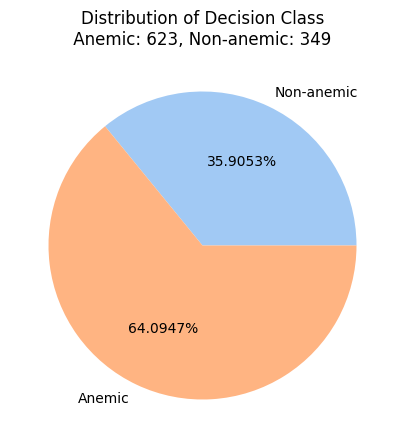

In [857]:
plt.figure(figsize=(5,5))

decision_counts = decision.value_counts().sort_index()

sns.set_palette('pastel')
plt.pie(decision_counts, labels=['Non-anemic', 'Anemic'], autopct='%.4f%%')

total_anemic = decision_counts.get(1)
total_non = decision_counts.get(0)
plt.title(f'Distribution of Decision Class\n Anemic: {total_anemic}, Non-anemic: {total_non} ')
plt.show()

The pie chart shows that **64.09%** of patients are classified as anemic (Decision Class = 1), while **35.90%** are non-anemic (Decision Class = 0). This confirms that the dataset is **imbalanced**, with Decison Class = 1 making up the majority. This imbalance is consistent with how the data was collected, since records were gathered from anemia patients at Aalok Healthcare Ltd., where vital signs and blood profiles were recorded at both diagnosis and follow-up visits to monitor disease progression.

This imbalance will be addressed at the later section of the notebook before model training.

### C. Demographic Distribution


#### Gender Distribution
Now, we'll take a look at how the patients are distributed by gender.

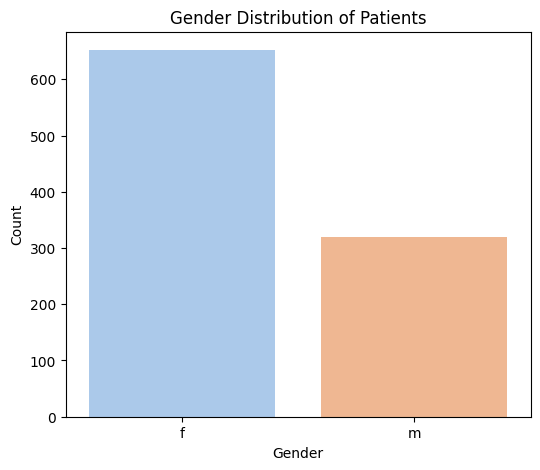

In [858]:
plt.figure(figsize=(6,5))

sns.countplot(data=anemia_df, x='gender', hue='gender', legend=False)
plt.title('Gender Distribution of Patients')
plt.xlabel('Gender')
plt.ylabel('Count')

plt.show()

The count plot shows that the dataset contains more **female** patients than **male** patients.

#### Age Distribution
Next, we'll take a look at how the ages of patients are distributed.

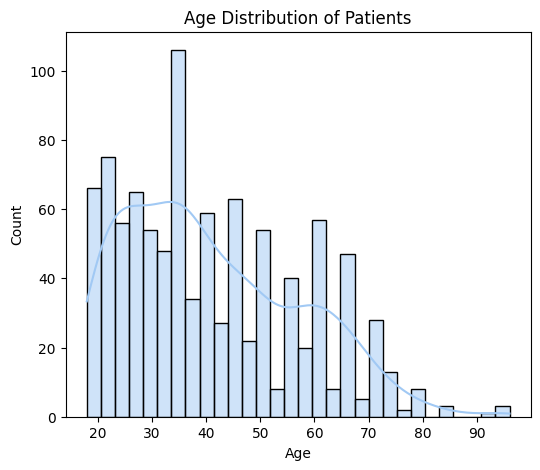

In [859]:
plt.figure(figsize=(6,5))

sns.histplot(data=anemia_df, x='age', bins=30, kde=True)
plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.ylabel('Count')

plt.show()

Upon observation, the age distribution appears **right-skewed**. With most patients in the range of **20 and 60 years of age** and fewer elderly patients represented in the dataset, consistent with what was noted in the descriptive statistics earlier.

### D. Hematological Parameters Distributions

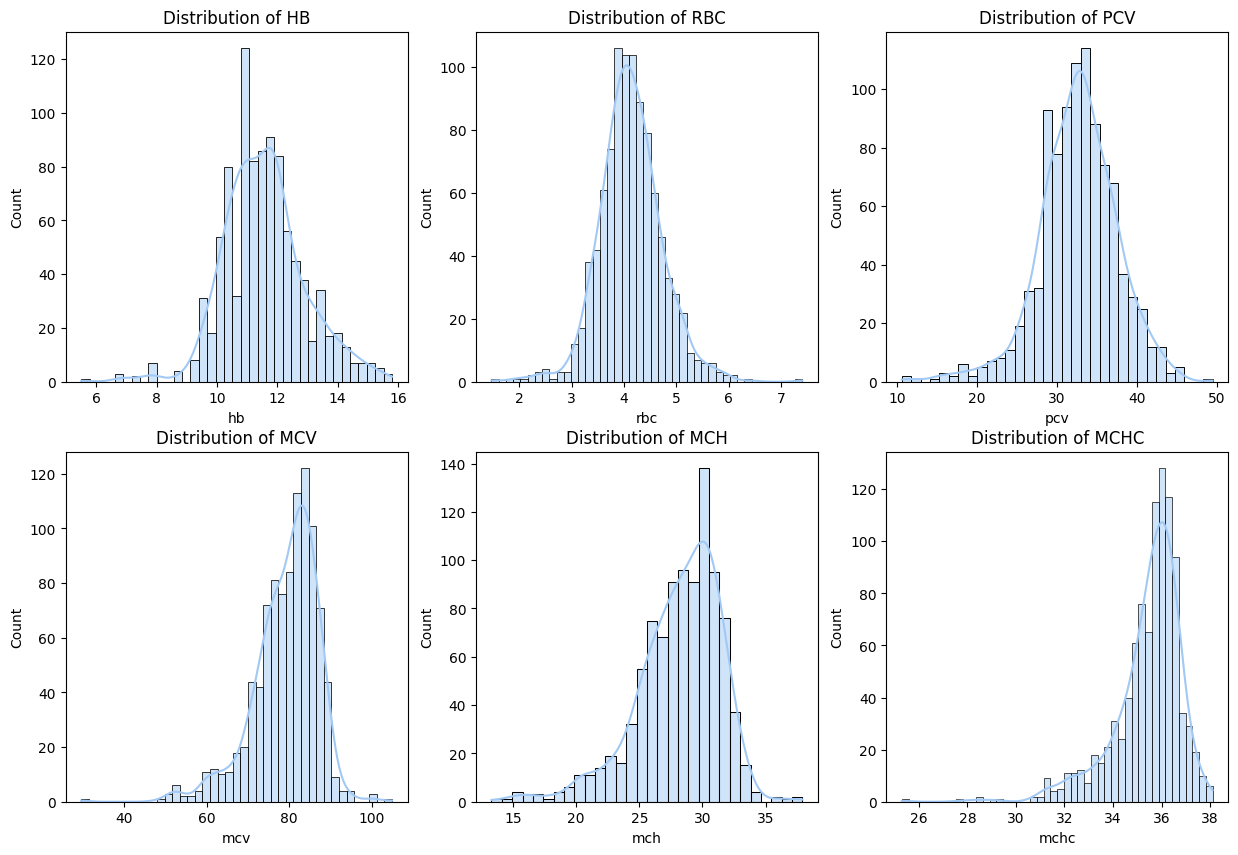

In [860]:
fig, axes = plt.subplots(2, 3, figsize=(15,10))

features = ['hb','rbc','pcv','mcv','mch','mchc']

for i, col in enumerate(features):
    ax = axes[i//3, i%3]
    sns.histplot(data=anemia_df, x=col, kde=True, ax=ax)
    ax.set_title(f'Distribution of {col.upper()}')

plt.show()

Given the results, it seems that most hematological parameters, including **Hb**, **RBC**, **PCV**, **MCV**, **MCH**, and **MCHC** display approximately normal or slightly skewed distributions. **MCHC** in particular shows the narrowest distribution range which was consistent with the descriptive statistics from earlier (smallest range).

**Outliers:**
Upon observation, notable outliers are visible in certain features. This was expected given that this is real-world clinical data. These extreme values might be because of the spectrum of anemia severity in the dataset, from mild to severe cases. As such, we decided to **retain these outliers** so that the model is not limited to learning from only moderate or average presentations of the condition.

### E. Hematological Features by Decision Class

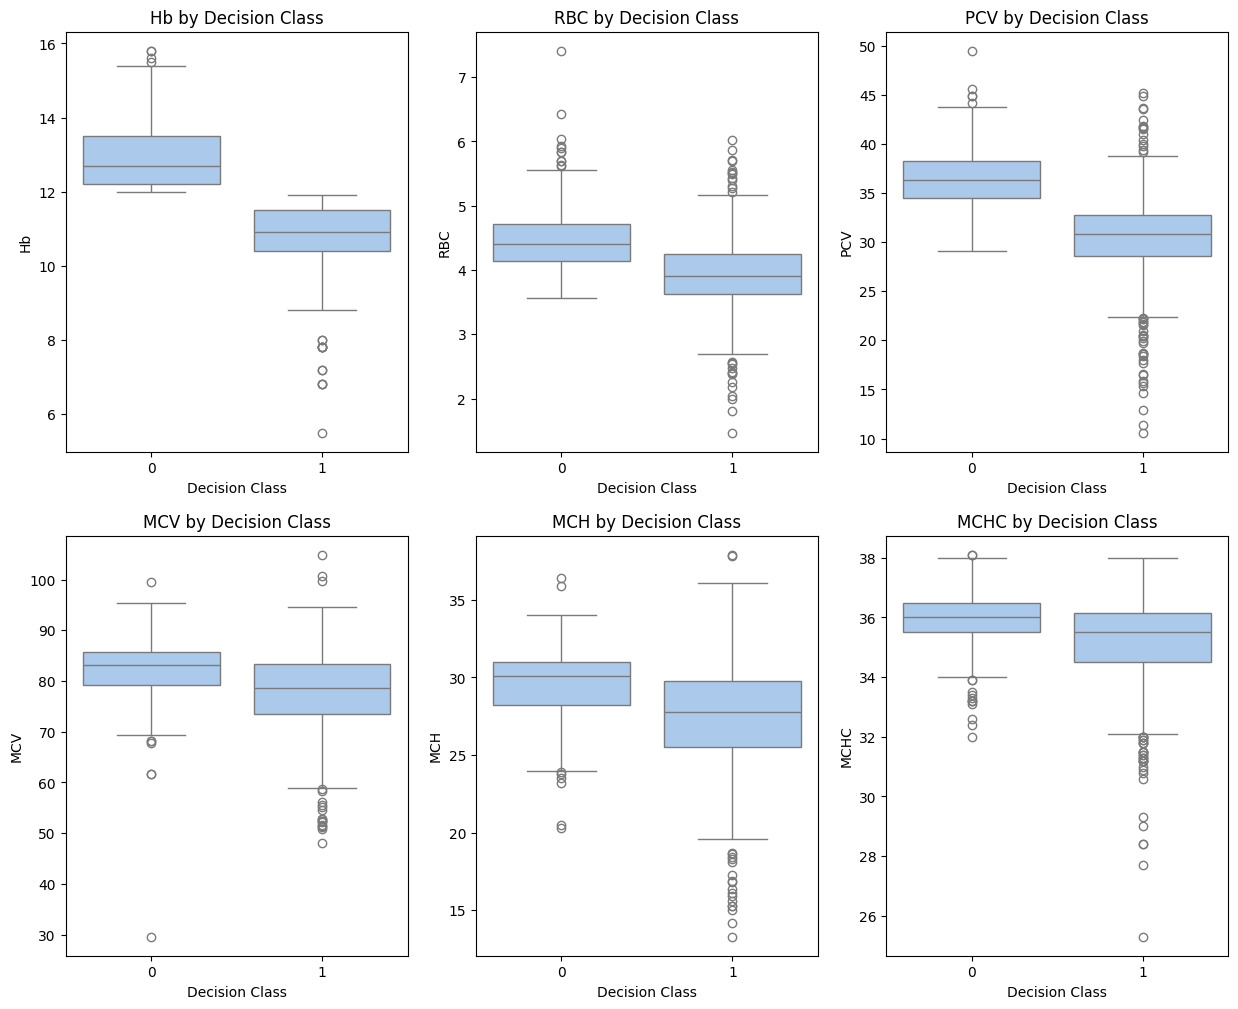

In [861]:
num_vars = [hb, rbc, pcv, mcv, mch, mchc]
num_labels = ['Hb', 'RBC', 'PCV', 'MCV', 'MCH', 'MCHC']

fig, axes = plt.subplots(2, 3, figsize=(15, 12))

axes = axes.flatten()

for i, (var, label) in enumerate(zip(num_vars, num_labels)):
    sns.boxplot(x=decision, y=var, ax=axes[i])

    axes[i].set_title(f'{label} by Decision Class')
    axes[i].set_xlabel('Decision Class')
    axes[i].set_ylabel(label)

plt.show()

Upon observation from the boxplots, it seems that there are clear differences in hematological parameters between anemic (1) and non-anemic (0) patients. **Hb**, **RBC**, and **PCV** are notably **lower** in anemic patients, which is expected since anemia is clinically characterized by reduced hemoglobin and red blood cell levels. **MCV** and **MCH** also tend to be lower in anemic cases, while **MCHC** shows a more subtle difference between the two classes. Given these results, most hematological features are useful inputs for the classification model.

### F. Demographic Relationships by Decision Class

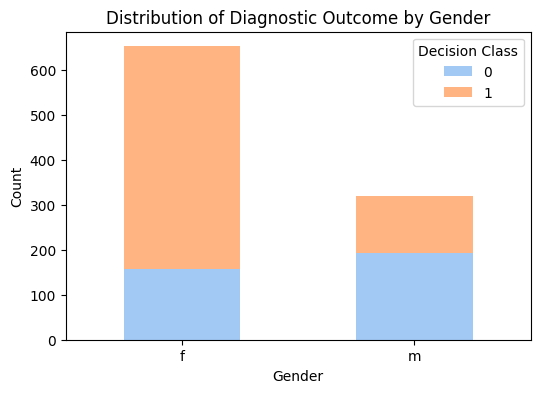

In [862]:
gender_decision = pd.crosstab(anemia_df['gender'], anemia_df['decision'])

gender_decision.plot(kind='bar', stacked=True, figsize=(6,4))

plt.title('Distribution of Diagnostic Outcome by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Decision Class')
plt.xticks(rotation=0)
plt.show()

Upon observation from the stacked bar chart, it seems that **anemia (Decision Class = 1) is more prevalent among female patients** compared to male patients. While males also show a proportion of anemic cases, the ratio of anemic to non-anemic patients is higher in females. This is consistent with studies indicating that females, particularly women of reproductive age, are at higher risk for anemia. [5]

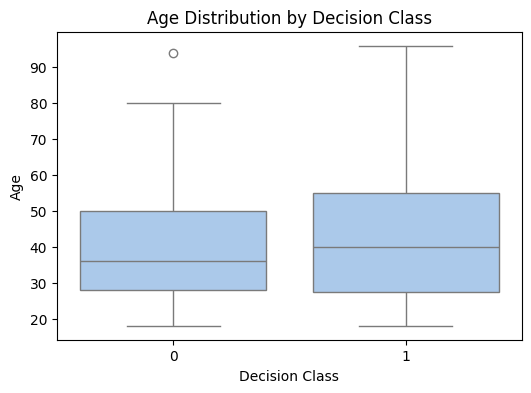

In [863]:
plt.figure(figsize=(6,4))
sns.boxplot(data=anemia_df, x='decision', y='age')
plt.title('Age Distribution by Decision Class')
plt.xlabel('Decision Class')
plt.ylabel('Age')
plt.show()

Upon observation from the boxplot, both anemic and non-anemic patients span a **similar age range**, with the median age being comparable between the two groups. However, the anemic group (Decision Class = 1) displays slightly wider spread, with some younger and older outliers. This suggests that **age alone may not be a strong predictor** of anemia in this dataset.

### G. Correlation of Variables
Now, we'll take a look at the correlation heatmap to understand the linear relationships between all numerical features and the target variable.

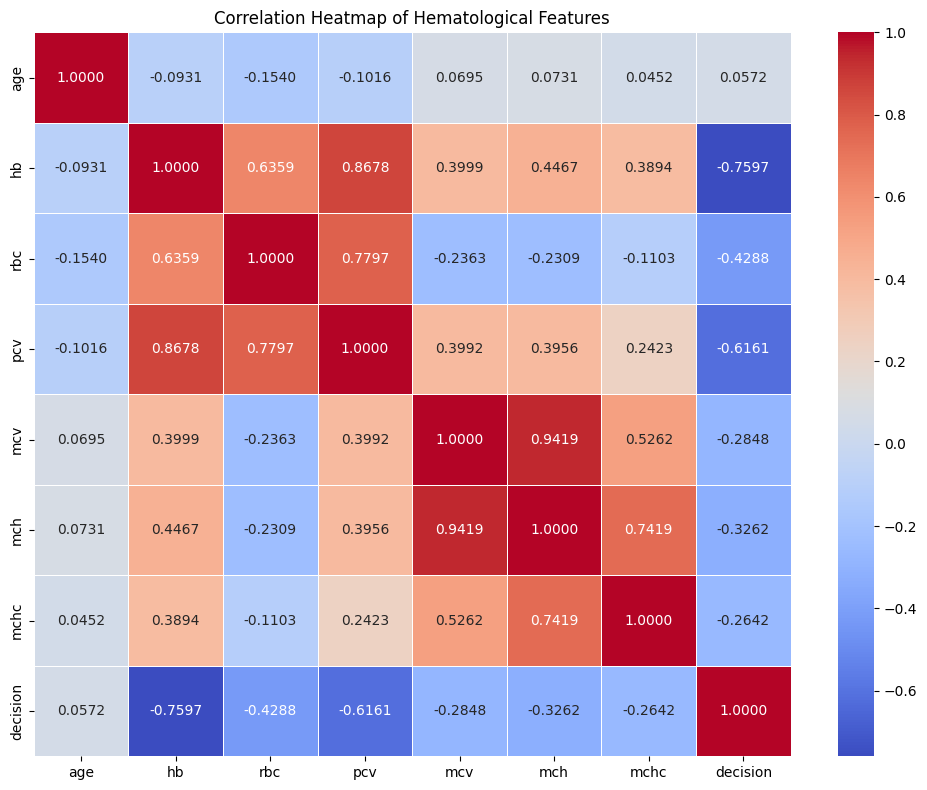

In [864]:
numeric_df = anemia_df.select_dtypes(include='number')

correlation = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, fmt='.4f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Hematological Features')
plt.tight_layout()
plt.show()

**Among hematological features**, **Hb**, **RBC**, and **PCV** exhibit strong positive intercorrelations (Hb-PCV: **0.8678**, RBC–PCV: **0.7797**, Hb–RBC: **0.6359**), which is expected as these three indices are directly related, a higher red blood cell count generally results in higher hemoglobin levels and packed cell volume [6]. **MCV** and **MCH** also show a very strong positive correlation (**0.9419**), indicating that larger red blood cells tend to contain more hemoglobin [7]. **MCHC** shows moderate correlations with MCH (**0.7419**) and MCV (**0.5262**).

**Regarding the target variable**, the strongest negative correlations are observed with **Hb** (**-0.7597**), **PCV** (**-0.6161**), and **RBC** (**-0.4288**), confirming that lower values in these parameters are strongly associated with anemia (Decision Class = 1). **MCH** (**-0.3262**), **MCV** (**-0.2848**), and **MCHC** (**-0.2642**) show weaker negative correlations with the target. Notably, it seems that **age** shows a near-zero correlation with the target (**0.0572**), meaning it has limited predictive value. This reinforces our earlier observation and the decision to remove it during feature selection.

Given these results, while the intercorrelations among hematological features show multicollinearity, we decided to **retain all hematological features** at this stage regardless. Since each represents a different hematological index and also has its own clinical interpretation and diagnostic relevance. We wanted to avoid the loss of clinically meaningful information.

## Section V. Data preprocessing

### A. Binary Mapping

The `gender` column contains categorical string values (`'f'` for female, `'m'` for male). We apply **binary mapping** to convert these values into numerical form by mapping `'f' → 0` and `'m' → 1`.

In [865]:
gender_scale = {'f': 0, 'm': 1}
anemia_df['gender'] = anemia_df['gender'].map(gender_scale)

anemia_df['gender']

0      0
1      0
2      0
3      1
4      0
      ..
995    0
996    1
997    1
998    0
999    0
Name: gender, Length: 972, dtype: int64

### B. Feature Selection

Aside from the exploratory data analysis, to support and assess whether each feature has a statistically significant relationship with the target variable (`decision`), we apply **SelectKBest** with the `f_classif`. This method returns an **F-score** and **p-value** for each. 

Features with a **p-value > 0.05** are considered statistically insignificant and are considered to be dropped prior to model training.

In [866]:
from sklearn.feature_selection import SelectKBest, f_classif

X = anemia_df.drop(columns='decision')
y = anemia_df['decision']

selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X, y)

feature_scores = pd.DataFrame({
    'feature': X.columns,
    'f-score': selector.scores_.round(4),
    'p-value': selector.pvalues_.round(4)
}).sort_values('p-value')

feature_scores

,feature,f-score,p-value
0,gender,137.0683,0.0000
2,hb,1324.1587,0.0000
3,rbc,218.5934,0.0000
4,pcv,593.5717,0.0000
5,mcv,85.6088,0.0000
6,mch,115.4814,0.0000
7,mchc,72.8164,0.0000
1,age,3.1872,0.0745


The results confirm the earlier EDA observation, `age` returned a p-value greater than 0.05, indicating that it does not have a statistically significant relationship with the diagnostic outcome. It is therefore dropped from the dataset prior to model training.

In [867]:
cols_to_drop = feature_scores[feature_scores['p-value'] > 0.05]['feature'].tolist()
print(f'Dropped features: {cols_to_drop}')

anemia_df = anemia_df.drop(columns=cols_to_drop)
print(f'Remaining features: {list(anemia_df.columns)}')

Dropped features: ['age']
Remaining features: ['gender', 'hb', 'rbc', 'pcv', 'mcv', 'mch', 'mchc', 'decision']


In [868]:
anemia_df

,gender,hb,rbc,pcv,mcv,mch,mchc,decision
0,0,10.9,4.26,34.2,80.2,25.5,31.8,1
1,0,9.6,3.64,29.9,82.1,26.4,32.2,1
2,0,10.1,3.70,32.4,87.6,27.4,31.3,1
3,1,11.0,3.93,33.6,85.3,27.9,32.7,1
4,0,12.1,4.16,36.5,87.9,29.2,33.2,0
...,...,...,...,...,...,...,...,...
995,0,10.4,4.49,28.4,63.2,21.2,33.5,1
996,1,13.7,4.37,37.8,86.6,31.4,36.2,0
997,1,12.1,4.17,33.5,80.4,28.9,36.0,0
998,0,12.2,4.28,33.5,78.4,28.6,36.5,0


### C. Train/Validation/Test Split
We split the dataset into **training (70%)**, **validation (15%)**, and **test (15%)** sets. In order to represent all classes in all sets, we do **stratification** (`stratify`).

In [869]:
X = anemia_df.drop(columns='decision')
y = anemia_df['decision']

print('X ', X.shape)
print('y ', y.shape)

X  (972, 7)
y  (972,)


In [870]:
# First split: train (70%) and test (30%) set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

In [871]:
# Second split: test (15%) and validation (15%) set
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=1, stratify=y_test)

In [872]:
print('Training set (X_train):', X_train.shape)
print('Training set (y_train):', y_train.shape)

print('Validation set (X_val):', X_val.shape)
print('Validation set (y_val):', y_val.shape)

print('Test set (X_test):', X_test.shape)
print('Test set (y_test):', y_test.shape)

Training set (X_train): (680, 7)
Training set (y_train): (680,)
Validation set (X_val): (146, 7)
Validation set (y_val): (146,)
Test set (X_test): (146, 7)
Test set (y_test): (146,)


In [873]:
# Check class distribution
print(y_train.value_counts(normalize=True))
print(y_val.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

decision
1    0.641176
0    0.358824
Name: proportion, dtype: float64
decision
1    0.643836
0    0.356164
Name: proportion, dtype: float64
decision
1    0.636986
0    0.363014
Name: proportion, dtype: float64


### D. Feature Scaling
Since the hematological features have different units and scales, we apply feature scaling to ensure that no single feature greatly influences our model due to its magnitude. **Standardization** (`StandardScaler`) is used, which transforms each feature to have a mean of 0 and a standard deviation of 1. This approach was chosen because (1) the outliers were retained in the dataset, and standardization is **less sensitive to outliers**, (2) the distributions follows an **approximately but not perfect normal distribution**. Moreover, in the process, the scalar is fitted only on the training set using `fit_transform`, and the mean and stddev are then applied to the validation and test sets using `transform` only to prevent any data leakage.

In [874]:
scaler = sklearn.preprocessing.StandardScaler()

features = ['hb', 'rbc', 'pcv', 'mcv', 'mch', 'mchc']

X_train[features] = scaler.fit_transform(X_train[features])
X_val[features] = scaler.transform(X_val[features])
X_test[features] = scaler.transform(X_test[features])

In [875]:
print('X_train:'), display(X_train.head())
print('X_val:'),   display(X_val.head())
print('X_test:'),  display(X_test.head())

X_train:


,gender,hb,rbc,pcv,mcv,mch,mchc
999,0,-0.583544,0.071846,0.484828,0.574569,0.485978,0.082348
660,1,1.052172,1.507797,0.840384,-0.864522,-0.739849,-0.062533
257,1,2.762239,2.795202,2.011624,-0.877487,-0.560460,0.589432
163,0,0.085613,-1.000991,0.171103,2.013660,1.502517,-0.279855
918,0,0.829120,-0.043690,0.714894,1.093160,0.874655,-0.062533


X_val:


,gender,hb,rbc,pcv,mcv,mch,mchc
117,0,-0.286141,-0.456320,-0.728242,-0.462614,-0.171783,0.734313
556,0,-1.327051,-0.736908,-2.255038,-2.562909,-2.503843,-1.583784
635,0,0.085613,-0.456320,-0.100792,0.509745,0.605571,0.589432
921,0,-0.286141,-0.456320,-0.100792,0.535674,0.635469,0.589432
607,0,1.275225,0.798074,0.965874,0.172660,0.216894,0.299669


X_test:


,gender,hb,rbc,pcv,mcv,mch,mchc
733,0,-0.360492,-0.538846,-0.372687,0.224520,0.336487,0.516991
173,0,0.531717,-0.126216,0.693979,1.209843,0.635469,-0.859379
662,0,0.606068,0.467971,0.212933,-0.410755,-0.022292,1.024075
818,0,-0.286141,-0.538846,-0.058962,0.730146,0.814858,0.661872
259,1,0.308665,0.682538,1.049534,0.431956,0.695265,1.096515


(None, None)

### E. Oversampling using SMOTE
From our EDA, the target variable is imbalanced, with the anemic class (decision = 1) comprising approximately **64%** of the dataset. To address this, we use a data-level approach: oversampling, particularly, by using Synthetic Minority Over-sampling Technique **(SMOTE)** from the `imbalanced-learn` library. This creates synthetic samples of the minority class. This produces a more balanced training distribution to prevent the model from being biased toward predicting the majority class.

In [876]:
# Count per class before applying SMOTE
print(y_train.value_counts())

decision
1    436
0    244
Name: count, dtype: int64


In [877]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=1)
X_train, y_train = smote.fit_resample(X_train, y_train)

print(y_train.value_counts())

decision
1    436
0    436
Name: count, dtype: int64


## Section VI. Model Selection & Training
The three models we have chosen are the following:
1. K-Nearest Neighbors
2. Logistic Regression
3. Neural Network

For each of these models, we will fit them to our training data, tune them with our validation sets, and perform final tests with our testing data.

### A. K-Nearest Neighbors

#### Model Fitting

To begin model training, import the KNeighborsClassifier class.

In [878]:
from sklearn.neighbors import KNeighborsClassifier

Instantiate a KNeighborsClassifier object with a random value for hyperparameter k.

In [879]:
model = KNeighborsClassifier(n_neighbors=1, metric='euclidean')

Train the model using fit() function with the X_train and y_train.

In [880]:
model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


#### Model Predicting

Evaluate the performance of the model by letting it predict with the validation data, X_val.

In [881]:
y_val_pred = model.predict(X_val)

Show the performance metrics given the actual predictions vs the predictions of the model with the validation data.

In [882]:
print('Classification Report:')
print(classification_report(y_val, y_val_pred, target_names=['Non-anemic', 'Anemic'], digits=4))

Classification Report:
              precision    recall  f1-score   support

  Non-anemic     0.8889    0.9231    0.9057        52
      Anemic     0.9565    0.9362    0.9462        94

    accuracy                         0.9315       146
   macro avg     0.9227    0.9296    0.9259       146
weighted avg     0.9324    0.9315    0.9318       146



With the metrics, the model predicted the correct class with an accuracy score of **93.15%**. We can say that the model was able to learn the data well. The recall score, which is relevant in this case, with non-anemic as the positive class is **92.31%**, while the score with anemic as the positive class is **93.62%**. These results mean that the model is able to catch **93.62%** of the anemic cases.

While the K-Nearest Neighbors model was able to capture the data and learn from it properly, this model is using the hyperparameter value of k=1, which is still not yet optimized. In addition, the high performance metrics can also indicate overfitting. We will tune the model with the best hyperparameters in the Error Analysis and Model Tuning.

#### Error Analysis and Model Tuning (Using validation set)

To see if the model is overfitting the data, we check the accuracy score of the model with the training dataset.

In [883]:
y_train_pred = model.predict(X_train)
print(f'Training Accuracy Score: {accuracy_score(y_train, y_train_pred)}')

Training Accuracy Score: 1.0


The accuracy scores of the model when making predictions on the training set is 100% compared to the 93.15% that is seen in the validation set. From this, we can see that there is possible overfitting to be seen.

We check when the model performs errors in predictions through displaying a confusion matrix.

Text(0.5, 1.0, 'Confusion Matrix for Validation Set')

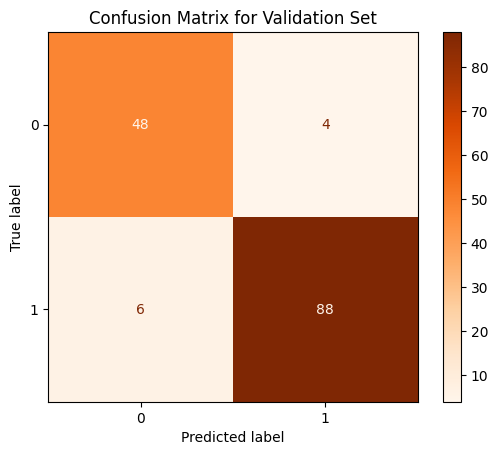

In [884]:
cm = confusion_matrix(y_val, y_val_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Oranges')
plt.title('Confusion Matrix for Validation Set')

From this confusion matrix, we can see that 6 anemic patients were mislabelled as non-anemic, and 4 non-anemic patients were mislabelled as anemic. Thus, we will tune the model to find the best possible value for hyperparameter k by iterating through different values for k (from 1-30) and seeing what provides the best **recall** score (see intro for why we will do model tuning
with recall score instead of accuracy).

In [885]:
rec_score = {}
n_neighbors = np.arange(1, 30, 1)

top_k = 0
top_k_rec = 0

for neighbor in n_neighbors:
    model = KNeighborsClassifier(n_neighbors=neighbor)

    # Fit to training data
    model.fit(X_train, y_train)

    # Test on validation data
    y_pred_val = model.predict(X_val)

    rec_score[neighbor] = recall_score(y_val, y_pred_val)

    # If accuracy is better, save the value of accuracy and the current k value
    if rec_score[neighbor] > top_k_rec:
        top_k_rec = rec_score[neighbor]
        top_k = neighbor

print(f"Best Recall: {top_k_rec:.4f}")
print("Optimized value for k: " + str(top_k))

Best Recall: 0.9468
Optimized value for k: 3


Plotting the recall score as we increase the value of k:

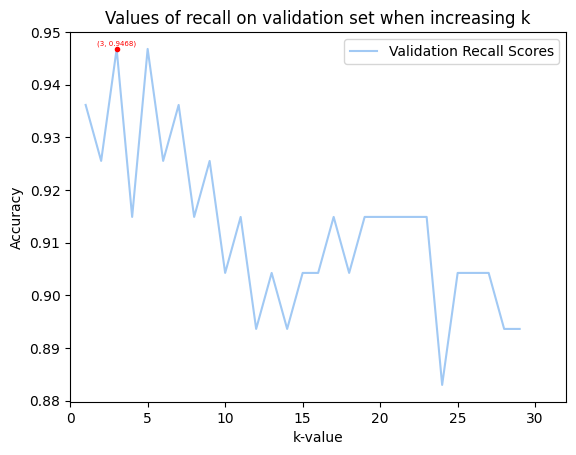

In [886]:
plt.plot(n_neighbors, rec_score.values(), label="Validation Recall Scores")
# plt.axvline(x=top_k, color='r', linestyle='--', linewidth=1)
plt.plot(top_k, top_k_rec, 'ro', ms=3)
plt.text(top_k - 1.3, top_k_rec  + 0.0007,  "(" + str(top_k) + ", " + str(round(top_k_rec, 4)) + ")", fontsize=5, color='red')
plt.plot()
plt.xlabel("k-value")
plt.ylabel("Accuracy")
plt.title("Values of recall on validation set when increasing k")
plt.legend()
plt.xlim(0, 32)
plt.show()

From here, we can determine that k = 3 is the best value for our knn, since it delivers the best recall score on the validation data.

#### Final Model Testing

With the best hyperparameter k, we now instantiate the K-Nearest Neighbors model with it.

In [887]:
model = KNeighborsClassifier(n_neighbors=3, metric='euclidean')

In [888]:
X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])

model.fit(X_train_val, y_train_val)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [889]:
y_predicted = model.predict(X_test)

In [890]:
print(f'Accuracy Score: {accuracy_score(y_test, y_predicted)}')

print('Classification Report:')
print(classification_report(y_test, y_predicted, target_names=['Non-anemic', 'Anemic'], digits=4))

Accuracy Score: 0.9383561643835616
Classification Report:
              precision    recall  f1-score   support

  Non-anemic     0.8929    0.9434    0.9174        53
      Anemic     0.9667    0.9355    0.9508        93

    accuracy                         0.9384       146
   macro avg     0.9298    0.9394    0.9341       146
weighted avg     0.9399    0.9384    0.9387       146



The K-Nearest Neighbors model was able to achieve a recall score of **93.55%** on Anemic patients, which means that **93.55%** of anemic patients were detected as anemic. Additionally, an accuracy of **93.83%** and a recall score of **94.34%** on non-anemic patients can also be seen.

### B. Logistic Regression

#### Model Fitting

To begin model training, import the `SGDClassifier` class.

In [891]:
from sklearn.linear_model import SGDClassifier

Instantiate an `SGDClassifier` with default hyperparameters first.

In [892]:
model = SGDClassifier(loss='log_loss')

Train the model using `fit()` function with the **X_train** and **y_train**.

In [893]:
model.fit(X_train, y_train)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'log_loss'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


#### Model Predicting

Evaluate the performance of the model by letting it predict with the validation data, **X_val**. We will use the `predict` function.

In [894]:
y_val_pred = model.predict(X_val)

Show the performance metrics given the actual predictions vs the predictions of the model with the validation data.

In [895]:
print(f'Accuracy Score: {accuracy_score(y_val, y_val_pred)}')

print('Classification Report:')
print(classification_report(y_val, y_val_pred, target_names=['Non-anemic', 'Anemic'], digits=4))

Accuracy Score: 0.9931506849315068
Classification Report:
              precision    recall  f1-score   support

  Non-anemic     0.9811    1.0000    0.9905        52
      Anemic     1.0000    0.9894    0.9947        94

    accuracy                         0.9932       146
   macro avg     0.9906    0.9947    0.9926       146
weighted avg     0.9933    0.9932    0.9932       146



With the metrics, the model predicted the correct class with an accuracy score of **99.32%**. We can say that the model was able to learn the data well. Due to the nature of this study, we can also look at the recall score to evaluate the performance. The recall score with non-anemic as the positive class is **100%**, while the score with anemic as the positive class is **98.94%**. These results mean that the model is able to catch **98.94% of the anemic cases**. 

While the Binary Logistic Regression model was able to capture the data well, it is important to note that this model has random hyperparameters and not yet optimized to have the best ones. In addition, the high performance metrics can also indicate overfitting. We will tune the model with the best hyperparameters in the **Error Analysis and Model Tuning**.

#### Error Analysis and Model Tuning

To see if the model is overfitting the data, we check the accuracy score of the model with the training dataset.

In [896]:
y_train_pred = model.predict(X_train)
print(f'Training Accuracy Score: {accuracy_score(y_train, y_train_pred)}')

Training Accuracy Score: 0.9954128440366973


The accuracy scores of the model when making predictions on the training and validation sets are both at around **99.66%**. Thus, it can be concluded that there is no overfitting.

We check when the model perform errors in predictions through displaying confusion matrix.

Text(0.5, 1.0, 'Confusion Matrix for Validation Set')

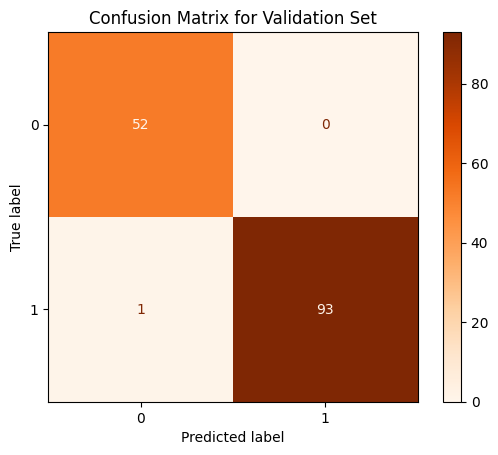

In [897]:
cm = confusion_matrix(y_val, y_val_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap='Oranges')
plt.title('Confusion Matrix for Validation Set')

As per the confusion matrix, the model mislabeled **2 anemic instances** with **non-anemic**. Thus, model will be tuned to find the best combination of hyperparameters of the logistic regression model through using `ParameterGrid`.

In [898]:
from sklearn.model_selection import ParameterGrid

model = SGDClassifier(loss='log_loss', random_state=42)
hyperparameters = {
    'penalty': ['l1', 'l2'],
    'max_iter': [100, 200, 300, 500, 1000],
    'learning_rate': ['constant', 'optimal'],
    'eta0': [0.001, 0.01, 0.1],
    'alpha': [0.0001, 0.001, 0.01]
}

In [899]:
best_score = 0
best_params = {}

for p in ParameterGrid(hyperparameters):
    model.set_params(**p)

    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    train_rec = recall_score(y_train, y_train_pred)

    y_val_pred = model.predict(X_val)
    val_rec = recall_score(y_val, y_val_pred)

    if val_rec > best_score:
        best_score = val_rec
        best_params = p

print(f'Best Recall Score: {best_score:.4f}')
print('Best Hyperparameters:', best_params)

Best Recall Score: 1.0000
Best Hyperparameters: {'alpha': 0.0001, 'eta0': 0.001, 'learning_rate': 'optimal', 'max_iter': 100, 'penalty': 'l1'}


#### Final Model Testing

With the best hyperparameters, we now instantiate the logistic regression model.

In [900]:
model = SGDClassifier(loss='log_loss', alpha=0.0001, eta0=0.001, learning_rate='optimal', max_iter=100, penalty='l1', random_state=42)

Train the model with the combined dataset of the train and validation sets.

In [901]:
model.fit(X_train_val, y_train_val)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'log_loss'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l1'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",100
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


Predict the classes of the test set instances.

In [902]:
y_pred = model.predict(X_test)

# For training set evaluation
y_train_pred = model.predict(X_train_val)

In [903]:
print(f'Training Accuracy: {accuracy_score(y_train_val, y_train_pred)}')
print(f'Test Accuracy: {accuracy_score(y_test, y_pred)}')

print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Non-anemic', 'Anemic'], digits=4))

Training Accuracy: 1.0
Test Accuracy: 1.0
Classification Report:
              precision    recall  f1-score   support

  Non-anemic     1.0000    1.0000    1.0000        53
      Anemic     1.0000    1.0000    1.0000        93

    accuracy                         1.0000       146
   macro avg     1.0000    1.0000    1.0000       146
weighted avg     1.0000    1.0000    1.0000       146



The logistic regression model was able to achieve an accuracy of **100%** for the train set and **100%** for the test set. These scores indicate that the model was able to capture the data well and did not overfit. Overall, the model is able to catch **100%** of the anemic cases. The model achieved full accuracy across data sets due to one of the features:

In [904]:
model.coef_

array([[ -0.40767546, -90.25390975,   1.25042678,  -1.17704107,
          0.3174234 ,   0.        ,   0.        ]])

Looking at the coeffecients of the features, `hb` attained the largest value than the other features with **-90.25**. This difference of magnitudes lead to `hb` being a critical decision marker to the model's predictions or outcomes. The model is learning the diagnostic criterion itself as diagnosing anemia is largely determined by hemoglobin levels.

### C. Neural Network

#### Model Fitting

To prepare the data for use with the `torch` module, convert all X and Y sets into `Tensor` float datatypes.

In [905]:
X_train_torch = torch.tensor(X_train.values).float()
y_train_torch = torch.tensor(y_train.values).float()

X_val_torch = torch.tensor(X_val.values).float()
y_val_torch = torch.tensor(y_val.values).float()

X_test_torch = torch.tensor(X_test.values).float()
y_test_torch = torch.tensor(y_test.values).float()

X_train, y_train

(     gender        hb       rbc       pcv       mcv       mch      mchc
 0         0 -0.583544  0.071846  0.484828  0.574569  0.485978  0.082348
 1         1  1.052172  1.507797  0.840384 -0.864522 -0.739849 -0.062533
 2         1  2.762239  2.795202  2.011624 -0.877487 -0.560460  0.589432
 3         0  0.085613 -1.000991  0.171103  2.013660  1.502517 -0.279855
 4         0  0.829120 -0.043690  0.714894  1.093160  0.874655 -0.062533
 ..      ...       ...       ...       ...       ...       ...       ...
 867       0  0.473804  0.528093  0.407996 -0.224615 -0.207983 -0.038138
 868       1  0.491718  1.553133  1.043178 -0.666359 -1.172237 -2.007421
 869       0  1.841425  2.373702  1.461416 -1.054006 -0.868663 -0.023605
 870       0  0.312060 -0.437554 -0.014267  0.614647  0.873289  1.159033
 871       0  1.604688  0.200083  0.997751  1.111136  1.229319  0.894812
 
 [872 rows x 7 columns],
 0      1
 1      0
 2      0
 3      1
 4      0
       ..
 867    0
 868    0
 869    0
 870   

For this portion, a custom neural network class was made to construct the network object for training. As the task at hand is a binary classification task, there will only be 1 output class. The `list_hidden` parameter is (4,10) as an initial value for the network, and the default activation function `relu` is used in between layers.

In [906]:
from neural_network import NeuralNetwork
network = NeuralNetwork(input_size=7, num_classes=1, list_hidden=(4,10), activation='relu')

In [907]:
network.create_network()
print(network)

NeuralNetwork(
  (layers): Sequential(
    (0): Linear(in_features=7, out_features=4, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=4, out_features=10, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=10, out_features=1, bias=True)
  )
)


Before training the network, reset all the weights in the network to 0 to avoid any bias in the process.

In [908]:
network.init_weights()


With the weights initialized and the training data converted into the correct datatype, initial training can be done. To train the system, use the `network.fit()` method. This iteratively trains the model until the loss minimizes into a small value. The initial `max_epochs` value is 400, with a `convergence_threshold` of 0.00005.

Before training, some variables need to be initialized. `BCEWithLogitsLoss` is used as the criterion as the network is built for binary classification. The optimizer used is `Adam` with a learning rate of `0.001`. Pass both of these into the training method.

In [909]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(params=network.parameters(), lr=0.001)

train_losses, val_losses, e = network.fit(X_train_torch, y_train_torch, X_val_torch, y_val_torch, criterion=criterion, optimizer=optimizer, verbose=True)

Epoch: 1 | Train Loss: 0.6939 | Val Loss: 0.6931 | Val Acc: 56.85%
Epoch: 10 | Train Loss: 0.6926 | Val Loss: 0.6926 | Val Acc: 52.05%
Epoch: 20 | Train Loss: 0.6914 | Val Loss: 0.6912 | Val Acc: 69.86%
Epoch: 30 | Train Loss: 0.6900 | Val Loss: 0.6892 | Val Acc: 78.08%
Epoch: 40 | Train Loss: 0.6878 | Val Loss: 0.6869 | Val Acc: 73.97%
Epoch: 50 | Train Loss: 0.6844 | Val Loss: 0.6828 | Val Acc: 74.66%
Epoch: 60 | Train Loss: 0.6787 | Val Loss: 0.6761 | Val Acc: 74.66%
Epoch: 70 | Train Loss: 0.6700 | Val Loss: 0.6659 | Val Acc: 74.66%
Epoch: 80 | Train Loss: 0.6581 | Val Loss: 0.6525 | Val Acc: 74.66%
Epoch: 90 | Train Loss: 0.6427 | Val Loss: 0.6355 | Val Acc: 73.97%
Epoch: 100 | Train Loss: 0.6242 | Val Loss: 0.6155 | Val Acc: 74.66%
Epoch: 110 | Train Loss: 0.6032 | Val Loss: 0.5928 | Val Acc: 76.71%
Epoch: 120 | Train Loss: 0.5808 | Val Loss: 0.5688 | Val Acc: 77.40%
Epoch: 130 | Train Loss: 0.5579 | Val Loss: 0.5441 | Val Acc: 78.08%
Epoch: 140 | Train Loss: 0.5351 | Val Loss: 0

The training loss is **0.2293** and the validation loss is **0.2147**, while not extremely high values, it suggests that the network still needs improvements. Given that this is unoptimized, this value would decrease should there be more adjustments to the model. However, the validation accuracy is **93.84%**, which suggests that the model was able to train relatively well.

#### Model Predicting

To evaluate the network, use the `classification_report` method from `sklearn`. Put the network on evaluation mode to prevent altering the values in the network while obtaining the statistics.

In [910]:
network.eval()

NeuralNetwork(
  (layers): Sequential(
    (0): Linear(in_features=7, out_features=4, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=4, out_features=10, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=10, out_features=1, bias=True)
  )
)

The validation set is used to get the predictions of the network. Perform one round of forward propagation to obtain the predictions.

In [911]:
with torch.no_grad():
    logits, probabilities = network.forward(X_val_torch)
    y_pred = network.predict(probabilities)

#### Error Analysis and Model Tuning

To get the metrics, first convert the predictions into a `numpy` array. Use `classification_report` to display the metrics of the network for analysis, and `confusion_matrix` to visualize the results.

              precision    recall  f1-score   support

  Non-anemic       0.86      0.98      0.92        52
      Anemic       0.99      0.91      0.95        94

    accuracy                           0.94       146
   macro avg       0.93      0.95      0.93       146
weighted avg       0.94      0.94      0.94       146



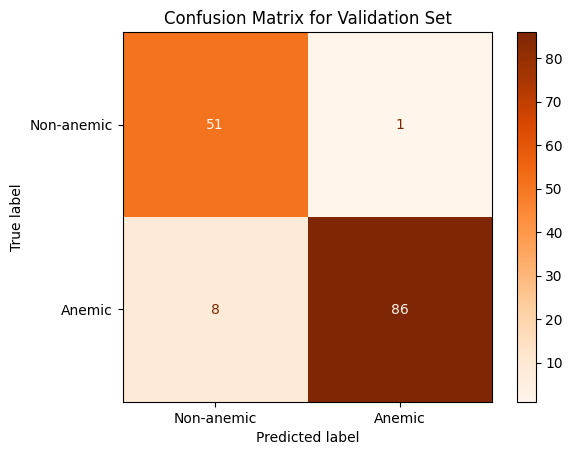

In [912]:
y_pred_numpy = y_pred.cpu().numpy()

print(classification_report(y_val, y_pred_numpy, target_names=['Non-anemic', 'Anemic'], zero_division=0))

cm = confusion_matrix(y_val, y_pred_numpy)
target_names = ['Non-anemic', 'Anemic']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap='Oranges', values_format='d') 
plt.title('Confusion Matrix for Validation Set')
plt.show()

The model has an accuracy of **94%**, which suggests that it was able to learn from the training set well. The recall for the anemic category is **91%**, suggesting that it was able to correctly predict 91% of the patients who were actually anemic. However, in the context of this dataset, misdiagnosing 9%, or 8 individuals, of these actually anemic patients as non-anemic is dangerous and may lead to insufficient care.

While the F1 scores imply that the model learned well from the training data, more adjustment is needed for the model to be more sensitive to the qualities of anemic patients. 

As there are multiple hyperparameters that can be adjusted to improve the losses of the network, the tuning process will be as follows
<ol>
    <li>adjust the parameters of the hidden layers</li>
    <li>adjust the learning rate</li>
    <li>adjust the maximum number of epochs for the model to converge</li>
</ol>

To simplify the process, two functions, `init_nn` and `evaluate_nn` will be made to quickly redo the process of testing new parameters.

In [913]:
def init_nn(X_train_torch, y_train_torch, X_val_torch, y_val_torch, list_hidden, epochs=400, convergence_threshold=0.00005, lr=0.001, verbose=False):
    net = NeuralNetwork(input_size=7, num_classes=1, list_hidden=list_hidden, activation='relu')
    
    net.create_network()
    net.init_weights()
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(params=net.parameters(), lr=lr)

    train_losses, val_losses, e = net.fit(X_train_torch, y_train_torch, X_val_torch, y_val_torch, criterion=criterion, optimizer=optimizer, max_epochs=epochs, convergence_threshold=convergence_threshold, verbose=verbose)
    print(train_losses, val_losses)

    return net, e

In [914]:
def evaluate_nn(network, X_val_torch, y_val):
    network.eval()
    with torch.no_grad():
        logits, probabilities = network.forward(X_val_torch)
        y_pred = network.predict(probabilities)
        
    y_pred_numpy = y_pred.cpu().numpy()

    print(f"Accuracy Score: {accuracy_score(y_val, y_pred_numpy): .4f}")
    print(classification_report(y_val, y_pred_numpy, target_names=['Non-anemic', 'Anemic'], zero_division=0))
    return recall_score(y_val, y_pred_numpy)

Adjusting the hidden layers may yield a lower loss value, as the network would be able to determine certain correlations between features. 

To do this, the model will be recreated using a list of hidden layer configurations that vary in both the number of neurons per network and the number of hidden layers in the network. Alongside this, every hidden layer configuration will tested with different learning rates as well. The maximum number of epochs will remain as 400, and will be adjusted should all models converge at the maximum number.

In [915]:
lists_hidden = [
    (2,),
    (4,),
    (8,),
    (16,),
    (4, 2),
    (8, 4),
    (16, 8),
    (16, 16),
    (32, 16),
    (32, 32),
    (16, 8, 4),
    (32, 16, 8)
]
lrs = [0.001, 0.0001, 0.005, 0.0005]

results_list = [] 

for config in lists_hidden:
    for rate in lrs:
        print(f"\nTesting Config: {config} | LR: {rate}")
        
        network, epochs = init_nn(X_train_torch, y_train_torch, X_val_torch, y_val_torch, 
                                  list_hidden=config, lr=rate)
        
        rec = evaluate_nn(network, X_val_torch, y_val) # This returns recall score
        
        results_list.append({
            'layers': config,
            'learning_rate': rate,
            'epochs': epochs,
            'recall': rec,
            'model': network
        })
        print(f"Result: Rec {rec:.4f} in {epochs} epochs")

sorted_results = sorted(results_list, key=lambda x: (x['recall'], -x['epochs']), reverse=True)

best_run = sorted_results[0]

print("\n" + "="*40)
print(f"Best model:")
print(f"Layers: {best_run['layers']}")
print(f"Learning Rate: {best_run['learning_rate']}")
print(f"Validation Recall Score: {best_run['recall']:.2%}")
print(f"Epochs to Converge: {best_run['epochs']}")
evaluate_nn(best_run['model'], X_val_torch, y_val)
print("="*40)


Testing Config: (2,) | LR: 0.001
[0.6948196887969971, 0.6947032809257507, 0.6945891976356506, 0.6944776177406311, 0.6943684220314026, 0.6942620873451233, 0.694159209728241, 0.694059431552887, 0.6939622163772583, 0.693867564201355, 0.6937747001647949, 0.693684458732605, 0.6935959458351135, 0.6935100555419922, 0.6934260129928589, 0.6933434009552002, 0.6932636499404907, 0.6931851506233215, 0.6931061148643494, 0.6930276155471802, 0.6929483413696289, 0.6928678750991821, 0.6927859783172607, 0.6927029490470886, 0.6926172375679016, 0.6925276517868042, 0.6924332976341248, 0.6923349499702454, 0.6922327876091003, 0.692125141620636, 0.6920125484466553, 0.6918944120407104, 0.6917707920074463, 0.6916415691375732, 0.6915067434310913, 0.6913657784461975, 0.6912168264389038, 0.6910609602928162, 0.6908983588218689, 0.6907285451889038, 0.6905503869056702, 0.6903635859489441, 0.6901674270629883, 0.6899623870849609, 0.689748227596283, 0.6895245909690857, 0.6892916560173035, 0.6890499591827393, 0.688800334

After multiple iterations of the possible hidden list and learning combinations, it was determined that the **(32, 16, 8)** hidden list combination and **0.005** is the best fit after 179 epochs. It scored a recall score of **100%**, with every metric (including accuracy) also scoring a perfect score. As this model converged below 400 epochs, no further adjustments will be made for this aspect of the model.

While this may seem like this is the best case scenario, it implies a major overfitting issue on the training and validation set. Regardless, this was the best fit combination found.

#### Final Model Testing

To check against model overfitting, evaluate the model using the test set.

Converged at epoch 180
[0.6922524571418762, 0.6903923749923706, 0.6885086297988892, 0.6861963272094727, 0.6833040714263916, 0.6797161102294922, 0.6753020882606506, 0.6700308322906494, 0.6637414693832397, 0.6563122272491455, 0.6476070880889893, 0.6375192403793335, 0.6259438395500183, 0.6127892732620239, 0.5980299711227417, 0.5817141532897949, 0.5639552474021912, 0.5450027585029602, 0.5252093076705933, 0.5050296187400818, 0.48496630787849426, 0.4655647873878479, 0.44723889231681824, 0.43016675114631653, 0.41412076354026794, 0.398724764585495, 0.3835046887397766, 0.3679910898208618, 0.3521184027194977, 0.3362525701522827, 0.3210252523422241, 0.3069591224193573, 0.2941431701183319, 0.2822207510471344, 0.27073854207992554, 0.2595515251159668, 0.2488383799791336, 0.2389426827430725, 0.23001490533351898, 0.22178837656974792, 0.21371124684810638, 0.20544177293777466, 0.1970316767692566, 0.18875724077224731, 0.18074966967105865, 0.17282389104366302, 0.1646953821182251, 0.15631960332393646, 0.14

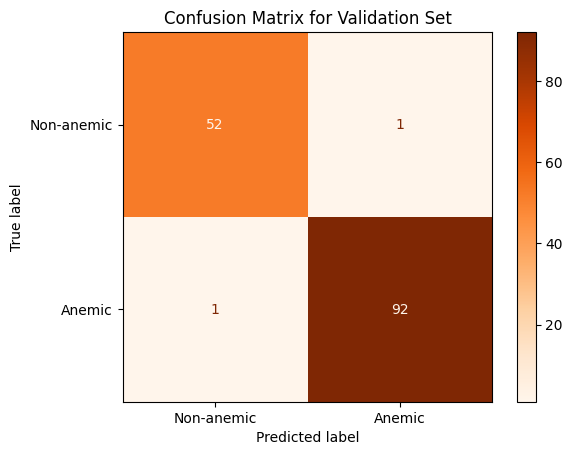

In [916]:
X_train_val_torch = torch.tensor(X_train_val.values).float()
y_train_val_torch = torch.tensor(y_train_val.values).float()

network, epochs = init_nn(X_train_val_torch, y_train_val_torch, X_test_torch, y_test_torch, 
                          list_hidden=best_run['layers'], lr=best_run['learning_rate'])

print("Recall Score for Anemic Patients : ", evaluate_nn(network, X_test_torch, y_test))

network.eval()
with torch.no_grad():
    logits, probabilities = network.forward(X_test_torch)
    y_pred = network.predict(probabilities)
    
y_pred_numpy = y_pred.cpu().numpy()

cm = confusion_matrix(y_test, y_pred_numpy)
target_names = ['Non-anemic', 'Anemic']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap='Oranges', values_format='d') 
plt.title('Confusion Matrix for Validation Set')
plt.show()

The model has an accuracy of **98.63%**, with a recall rate of **99%** on the anemic category. Compared to the unoptimized model, it's more capable of catching anemic patients by 0.08% (based on the recall scores). The model also shows sufficient training without overfitting the training data as evidenced by the near-perfect metrics from the test data.

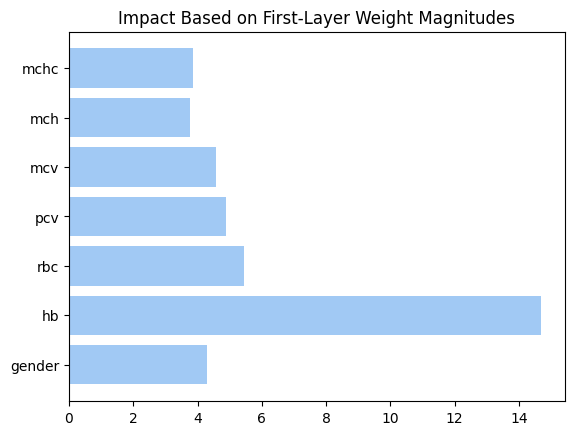

In [917]:
weights = network.layers[0].weight.abs().detach().cpu().numpy()

summed_weights = weights.sum(axis=0)
features = X_train.columns

plt.barh(features, summed_weights)
plt.title("Impact Based on First-Layer Weight Magnitudes")
plt.show()

The bar chart above shows that **hb** is the most significant input for determining if a patient is anemic or not. Thus, the model has correctly learned the main diagnostic criteria for detecting anemia in patients.

## Section VII. Model Evaluation

## References:
[1]: Billett, H. H. (1990). Hemoglobin and hematocrit. Clinical Methods - NCBI Bookshelf. https://www.ncbi.nlm.nih.gov/books/NBK259/ 

[2]: Dean, L. (n.d.). Table 1, Complete blood count - Blood Groups and Red Cell Antigens - NCBI Bookshelf. https://www.ncbi.nlm.nih.gov/books/NBK2263/table/ch1.T1/

[3]: Hematocrit (Packed cell Volume-PCV). (n.d.). https://www.healthcare.uiowa.edu/path_handbook/rhandbook/test955.html

[4]: Liess, B. (2025, August 14). Mean Corpuscular Hemoglobin (MCH) and Mean Corpuscular Hemoglobin Concentration (MCHC). Medscape. https://emedicine.medscape.com/article/2054497-overview?form=fpf

[5]: Mojumdar, M. U., Sarker, D., Assaduzzaman, M., Sajeeb, M. A. H., Rahman, M. M., Bari, M. S., ... & Chakraborty, N. R. (2025). AnaDetect: An extensive dataset for advancing anemia detection, diagnostic methods, and predictive analytics in healthcare. Data in Brief, 58, 111195. 

[6]: Professional C. C. M. (2025, December 24). High red blood cell count. Cleveland Clinic. https://my.clevelandclinic.org/health/symptoms/17810-high-red-blood-cell-count

[7]: Chicoine, B. (2025, February). MCH and MCV: Differences in Red Blood Cells of People with Down Syndrome. Advocate Medical Group: Adult Down Syndrome Center. https://adscresources.advocatehealth.com/resources/mch-and-mcv/

[8]: Microcytic anemia. (2025, December 24). Cleveland Clinic. http://my.clevelandclinic.org/health/diseases/23015-microcytic-anemia